# 

In [71]:
from pathlib import Path
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
###################### UTILITY IMPORTS ######################

from utils.Utils import (
    collect_png_images,
    read_gray,
    correct_image_type,
    show_image_comparison,
    show_image,
    save_image,
    save_image_inventory,
    save_df_to_csv
)

from utils.A_Metadata_Crop import (
    IMAGE_EXTENSIONS
)

# Image Preprocessing Functions

## Contrast Normalization - MINMAX normalization

In [73]:
def contrast_normalize(image, show_transformation = False):
    """
    Normalize an image to the range [0, 255] and convert/verify image is uint8.

    Parameters:
    * image: input image (any numeric type)

    Returns:
    * normalized uint8 image
    """

    # normalize pixel values to 0-255
    normalized_image = cv2.normalize(
        image, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX
    )

    # validate uint8 format
    normalized_image = correct_image_type(normalized_image)

    if show_transformation:
        show_image_comparison(image, normalized_image, title1="Before Normalization", title2="After Normalization")

    return normalized_image


## Denoising - Gaussian, Median, NL Means

In [74]:
def denoise_image(image, method="median", show_transformation = False):
    """
    Denoise an image using the selected denoising method.

    Parameters:
    * image: input image (uint8)
    * method: denoising method ("gaussian", "median", or "nl_means")
    * show_transformation: if True, displays original and denoised images

    Returns:
    * denoised: noise-reduced image (uint8)
    """
    image = image.astype(np.uint8)

    if method == "gaussian":
        denoised_image = cv2.GaussianBlur(image, (5, 5), 0)

    elif method == "median":
        denoised_image = cv2.medianBlur(image, 5)

    elif method == "nl_means":
        denoised_image = cv2.fastNlMeansDenoising(image, None, h=10)

    else:
        raise ValueError(f"Unknown denoising method: {method}. Options include 'gaussian;", 'median', 'nl_means')

    if show_transformation:
        show_image_comparison(image, denoised_image, title1="Before Denoising", title2="After Denoising")

    return denoised_image

### Otsu Thresholding - Grayscale --> Binary

In [ ]:
def otsu_binarize(image, show_transformation=False):
    """
    Binarize a grayscale image using CLAHE-enhanced Otsu thresholding with
    post-processing to remove small connected components and improve vertical
    connectivity.

    Parameters
    ----------
    image : numpy.ndarray
        Input image. The image is converted to a valid grayscale format using
        `correct_image_type()` before processing.
    show_transformation : bool, optional
        If True, displays a side-by-side comparison of the original and
        binarized images. Default is False.

    Returns
    -------
    binary_img : numpy.ndarray
        Binary image where foreground pixels have value 255 and background
        pixels have value 0.
    adjusted_threshold : float
        Threshold value used for final binarization, computed as 75% of the
        Otsu threshold.

    Implementation Details
    ----------------------
    1. Normalize the input image type with `correct_image_type()`.
    2. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization) to
       enhance local contrast.
    3. Compute the Otsu threshold on the enhanced image.
    4. Reduce the Otsu threshold to 75% to improve foreground retention.
    5. Perform binary thresholding using the adjusted value.
    6. Remove small connected components (area < 6 px or height < 3 px).
    7. Apply a vertical morphological closing operation with a (1x2) kernel
       to reconnect small gaps in foreground structures.
    8. Optionally visualize the transformation and print the threshold values.
    """

    image = correct_image_type(image)


    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    enhanced = clahe.apply(image)

    
    otsu_threshold, _ = cv2.threshold(
        enhanced,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )



    adjusted_threshold = otsu_threshold * 0.75


    _, binary_img = cv2.threshold(
        enhanced,
        adjusted_threshold,
        255,
        cv2.THRESH_BINARY
    )

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_img, 8)

    cleaned = np.zeros_like(binary_img)
    

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        height = stats[i, cv2.CC_STAT_HEIGHT]

        if area >= 6 and height >= 3:
            cleaned[labels==i] = 255
    
    vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,2))
    binary_img = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, vertical_kernel, iterations=1)


    if show_transformation:
        show_image_comparison(
            image,
            binary_img,
            title1="Before Otsu Binarization",
            title2=f"Otsu Binary | T={adjusted_threshold:.1f}"
        )

    
    print(
        f"Otsu={otsu_threshold:.1f}, "
        f"Adjusted={adjusted_threshold:.1f}"
    )



    return binary_img, adjusted_threshold



### Background Colour Detection

In [76]:
def detect_binary_background(image, show_stats=False):
    """
    Determine the background colour of a binary image.

    The colour containing the majority of pixels is assumed to be
    the background.

    Returns:
    * background_value: 0 for black or 255 for white
    * white_count: number of white pixels
    * black_count: number of black pixels
    """
    image = correct_image_type(image)

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Using >= 128 and < 128 also makes this safe if a few pixels are not exactly 0 or 255
    white_count = int(np.count_nonzero(image >= 128))
    black_count = int(np.count_nonzero(image < 128))

    if white_count >= black_count:
        background_value = 255
        background_name = "white"
    else:
        background_value = 0
        background_name = "black"

    if show_stats:
        print(f"Detected background: {background_name}")
        print(f"White pixels: {white_count:,}")
        print(f"Black pixels: {black_count:,}")
        print(f"White fraction: {white_count / image.size:.3f}")

    return background_value, white_count, black_count

### Morphological Opening and Closing

In [77]:
# temporary inversion for images with white background
def ensure_black_background(image, show_transformation=False):
    """
    Ensure that a binary image has a black background before
    morphology and strip removal.

    White-background images are inverted once.
    Black-background images are left unchanged.

    Returns:
    * output_image
    * was_inverted
    """
    image = correct_image_type(image)

    background_value, white_count, black_count = (
        detect_binary_background(image)
    )

    if background_value == 255:
        output_image = cv2.bitwise_not(image)
        was_inverted = True
        action = "White background detected — inverted to black"
    else:
        output_image = image.copy()
        was_inverted = False
        action = "Black background detected — no inversion"

    if show_transformation:
        show_image_comparison(
            image,
            output_image,
            title1="Before Background Check",
            title2=action
        )

    return output_image, was_inverted

In [78]:
def morphologically_close(image, iterations=1, dilation_kernel_size = (1,2), erosion_kernel_size = (1,2), show_transformation = False):
    """
    Apply morphological closing to fill small holes/gaps.

    Parameters:
    * image: binary or grayscale image (uint8)
    * kernel_size: size of structuring element
    * iterations: number of times operation is applied

    Returns:
    * closed image
    """
    image = correct_image_type(image)

    erosion_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        erosion_kernel_size
    )

    dilation_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        dilation_kernel_size
    )

    closed_image = cv2.dilate(
        image,
        dilation_kernel,
        iterations=iterations
    )

    closed_image = cv2.erode(
        closed_image,
        erosion_kernel,
        iterations=1
    )

    if show_transformation:
        show_image_comparison(image, closed_image, title1="Before Closing", title2="After Closing")

    return closed_image

### Horizontal Edge Detection and Empty-Space Cleanup

In [79]:
def _merge_nearby_rows(
    candidate_rows,
    row_strength,
    merge_distance=4
):
    """
    Merge nearby detected rows so one thick horizontal edge is
    represented by one row.

    Returns all distinct merged edges, ordered from top to bottom.
    """
    if len(candidate_rows) == 0:
        return []

    candidate_rows = np.array(sorted(candidate_rows))

    groups = []
    current_group = [candidate_rows[0]]

    for row in candidate_rows[1:]:
        if row - current_group[-1] <= merge_distance:
            current_group.append(row)
        else:
            groups.append(current_group)
            current_group = [row]

    groups.append(current_group)

    detected_rows = []

    for group in groups:
        group = np.asarray(group, dtype=int)

        # Use the strongest row to represent this particular thick edge.
        strongest_row = group[
            np.argmax(row_strength[group])
        ]

        detected_rows.append(int(strongest_row))

    return sorted(detected_rows)

In [80]:
def detect_horizontal_edges(
    image,
    min_line_length_fraction=0.03,
    max_line_gap=10,
    max_vertical_difference=2,
    ignore_margin=5,
    merge_distance=4,
    show_transformation=False,
    debug=False
):
    """
    Detect genuine long horizontal lines without connecting separate
    character strokes into artificial edges.

    Parameters
    ----------
    image:
        Grayscale or binary uint8 image.

    min_line_length_fraction:
        Minimum detected line length as a fraction of image width.

    max_line_gap:
        Maximum gap, in pixels, that may exist within one detected line.
        Keep this small so metadata characters are not joined together.

    max_vertical_difference:
        Maximum allowed change in y-coordinate between the two endpoints.
        This rejects diagonal lines.

    ignore_margin:
        Ignore detections too close to the top or bottom image boundary.

    merge_distance:
        Merge nearby rows belonging to the same thick horizontal line.

    Returns
    -------
    edge_rows:
        Detected horizontal edge rows, ordered from top to bottom.

    horizontal_edges:
        Visualization image containing accepted line detections.

    row_strength:
        Fraction of each row covered by accepted line detections.
    """
    image = correct_image_type(image)

    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    height, width = image.shape

    blurred = cv2.GaussianBlur(
        image,
        (3, 3),
        0
    )

    edges = cv2.Canny(
        blurred,
        threshold1=50,
        threshold2=150
    )

    min_line_length = max(
        15,
        int(width * min_line_length_fraction)
    )

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=max(15, min_line_length // 4),
        minLineLength=min_line_length,
        maxLineGap=max_line_gap
    )

    horizontal_edges = np.zeros_like(edges)

    accepted_lines = []

    if lines is not None:
        for line in lines[:, 0]:
            x1, y1, x2, y2 = map(int, line)

            line_length = abs(x2 - x1)
            vertical_difference = abs(y2 - y1)

            # Reject short or noticeably angled lines.
            if line_length < min_line_length:
                continue

            if vertical_difference > max_vertical_difference:
                continue

            row = int(round((y1 + y2) / 2))

            # Ignore the outer image boundary.
            if row < ignore_margin:
                continue

            if row >= height - ignore_margin:
                continue

            accepted_lines.append(
                {
                    "row": row,
                    "x1": min(x1, x2),
                    "x2": max(x1, x2),
                    "length": line_length
                }
            )

            cv2.line(
                horizontal_edges,
                (x1, row),
                (x2, row),
                255,
                thickness=1
            )

    row_strength = (
        horizontal_edges > 0
    ).mean(axis=1)

    candidate_rows = np.array(
        [line["row"] for line in accepted_lines],
        dtype=int
    )

    edge_rows = _merge_nearby_rows(
        candidate_rows=candidate_rows,
        row_strength=row_strength,
        merge_distance=merge_distance
    )

    if debug:
        print("\n==============================")
        print("HORIZONTAL EDGE DETECTION DEBUG")
        print("==============================")
        print(f"Image shape: {image.shape}")
        print(f"Minimum line length: {min_line_length}")
        print(f"Maximum line gap: {max_line_gap}")
        print(f"Accepted Hough lines: {accepted_lines}")
        print(f"Merged edge rows: {edge_rows}")

    if show_transformation:
        show_image_comparison(
            image,
            horizontal_edges,
            title1="Input Image",
            title2=f"Detected Horizontal Edges: {edge_rows}"
        )

    return edge_rows, horizontal_edges, row_strength

In [81]:
def color_empty_space_black(
    image,
    edge_rows,
    background_value=0,
    edge_padding=4,
    split_row=None,
    show_transformation=False
):
    """
    Color unnecessary outer space black, including the detected
    horizontal boundary and several neighboring rows.

    Parameters:
    * image: binary or grayscale uint8 image
    * edge_rows: detected horizontal edge row indices
    * background_value: value used for removed areas, normally 0
    * edge_padding: extra rows removed around each detected edge
    * split_row: row dividing top and bottom regions. If None,
      uses half the actual image height.
    * show_transformation: display before/after comparison

    Returns:
    * cleaned image
    """
    image = correct_image_type(image)
    cleaned_image = image.copy()

    height = cleaned_image.shape[0]

    if split_row is None:
        split_row = height // 2

    for row in edge_rows:
        if row < split_row:
            # Include the detected edge and rows just below it.
            cleanup_end = min(
                height,
                row + edge_padding + 1
            )

            cleaned_image[:cleanup_end, :] = background_value

        else:
            # Include the detected edge and rows just above it.
            cleanup_start = max(
                0,
                row - edge_padding
            )

            cleaned_image[cleanup_start:, :] = background_value
    
    if show_transformation:
        show_image_comparison(
            image,
            cleaned_image,
            title1="Before Empty-Space Cleanup",
            title2=(
                f"After Cleanup | Edges: {edge_rows} | "
                f"Padding: {edge_padding}"
            )
        )

    return cleaned_image

In [82]:
def remove_unwanted_strips(
    image,
    detection_image=None,
    min_line_length_fraction=0.03,
    max_line_gap=10,
    safety_padding=1,
    show_transformation=False,
    debug=False
):
    """
    Remove unwanted top and bottom strips.

    image:
        Image that will actually be cleaned.

    detection_image:
        Image used only for detecting horizontal boundaries.
        Prefer the binary image before morphological closing.
    """
    image = correct_image_type(image)

    if detection_image is None:
        detection_image = image

    detection_image = correct_image_type(detection_image)

    edge_rows, horizontal_edges, row_strength = (
        detect_horizontal_edges(
            image=detection_image,
            min_line_length_fraction=min_line_length_fraction,
            max_line_gap=max_line_gap,
            ignore_margin=5,
            merge_distance=4,
            show_transformation=False,
            debug=debug
        )
    )

    cleaned_image = image.copy()

    height = cleaned_image.shape[0]
    split_row = height // 2

    top_edge_rows = [
        row
        for row in edge_rows
        if row < split_row
    ]

    bottom_edge_rows = [
        row
        for row in edge_rows
        if row >= split_row
    ]

    selected_top_edge = (
        min(top_edge_rows)
        if top_edge_rows
        else None
    )

    selected_bottom_edge = (
        max(bottom_edge_rows)
        if bottom_edge_rows
        else None
    )

    top_cleanup_end = None
    bottom_cleanup_start = None

    if selected_top_edge is not None:
        top_cleanup_end = min(
            height,
            selected_top_edge
            + safety_padding
            + 1
        )

    if selected_bottom_edge is not None:
        bottom_cleanup_start = max(
            0,
            selected_bottom_edge
            - safety_padding
        )

    if debug:
        print("\n==============================")
        print("REMOVE UNWANTED STRIPS DEBUG")
        print("==============================")
        print(f"Image height: {height}")
        print(f"Split row: {split_row}")
        print(f"Detected edge rows: {edge_rows}")
        print(f"Top-region edges: {top_edge_rows}")
        print(f"Bottom-region edges: {bottom_edge_rows}")
        print(f"Selected top edge: {selected_top_edge}")
        print(f"Selected bottom edge: {selected_bottom_edge}")
        print(f"Top cleanup end: {top_cleanup_end}")
        print(f"Bottom cleanup start: {bottom_cleanup_start}")

    if (
        top_cleanup_end is not None
        and bottom_cleanup_start is not None
        and top_cleanup_end >= bottom_cleanup_start
    ):
        print(
            "WARNING: Cleanup regions overlap. "
            "Returning original image."
        )
        return image.copy()

    if top_cleanup_end is not None:
        cleaned_image[:top_cleanup_end, :] = 0

    if bottom_cleanup_start is not None:
        cleaned_image[bottom_cleanup_start:, :] = 0

    if show_transformation:
        show_image_comparison(
            image,
            cleaned_image,
            title1="Before Strip Removal",
            title2=(
                "After Strip Removal\n"
                f"All edges: {edge_rows} | "
                f"Selected: {selected_top_edge}, "
                f"{selected_bottom_edge}"
            )
        )

    return cleaned_image

### Invert Image - Black to White, White to Black

In [83]:
def invert_image(image, show_transformation=False):
    """
    Invert image pixels.

    For binary images:
    * black 0 becomes white 255
    * white 255 becomes black 0
    """
    image = correct_image_type(image)

    inverted_image = cv2.bitwise_not(image)

    if show_transformation:
        show_image_comparison(
            image,
            inverted_image,
            title1="Before Inversion",
            title2="After Inversion"
        )

    return inverted_image

### Final Preprocessing - Normalization

In [84]:
def normalize_to_float(image):
    """
    Normalize final image pixel values to [0, 1].

    This should be done at the end, after thresholding, cleanup,
    inversion, padding/resizing, etc.
    """
    image = np.asarray(image)

    if image.dtype == np.uint8:
        return image.astype(np.float32) / 255.0

    image = image.astype(np.float32)

    if image.max() > 1.0:
        image = image / 255.0

    return image

## Testing Pipeline on Test Images


Testing: L:\DATA\ISIS\2026-June-Model-Training\Cropped_Images\SSA-23\23-001\image213.png
1. Contrast normalization


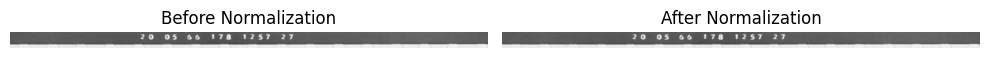

2. Median denoising


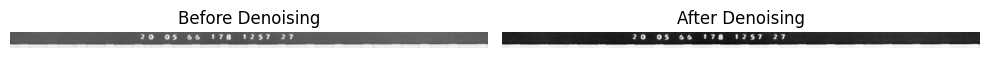

3. Otsu binarization


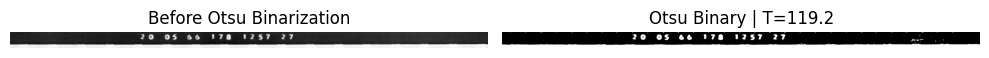

Otsu=159.0, Adjusted=119.2
4. Background standardization


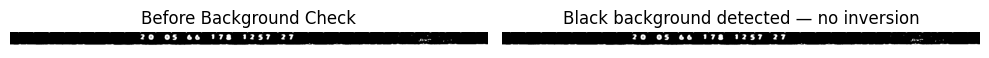

5. Morphological closing


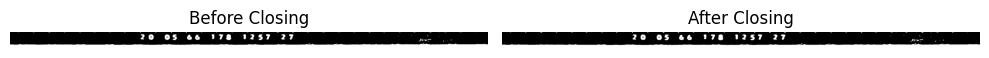

6. Horizontal edge detection

HORIZONTAL EDGE DETECTION DEBUG
Image shape: (100, 2952)
Minimum line length: 88
Maximum line gap: 10
Accepted Hough lines: [{'row': 79, 'x1': 1172, 'x2': 1294, 'length': 122}, {'row': 78, 'x1': 54, 'x2': 157, 'length': 103}, {'row': 77, 'x1': 2761, 'x2': 2879, 'length': 118}, {'row': 79, 'x1': 1702, 'x2': 1821, 'length': 119}, {'row': 78, 'x1': 230, 'x2': 318, 'length': 88}]
Merged edge rows: [79]


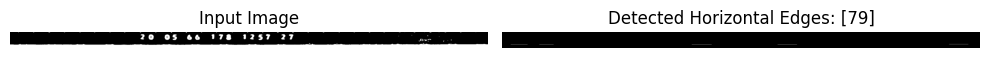

7. Strip removal

HORIZONTAL EDGE DETECTION DEBUG
Image shape: (100, 2952)
Minimum line length: 88
Maximum line gap: 10
Accepted Hough lines: [{'row': 79, 'x1': 1172, 'x2': 1294, 'length': 122}, {'row': 78, 'x1': 54, 'x2': 157, 'length': 103}, {'row': 77, 'x1': 2761, 'x2': 2879, 'length': 118}, {'row': 79, 'x1': 1702, 'x2': 1821, 'length': 119}, {'row': 78, 'x1': 230, 'x2': 318, 'length': 88}]
Merged edge rows: [79]

REMOVE UNWANTED STRIPS DEBUG
Image height: 100
Split row: 50
Detected edge rows: [79]
Top-region edges: []
Bottom-region edges: [79]
Selected top edge: None
Selected bottom edge: 79
Top cleanup end: None
Bottom cleanup start: 78


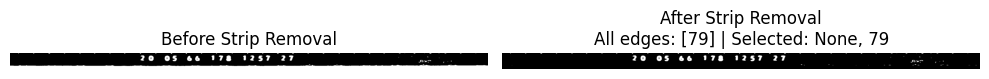

8. Final inversion


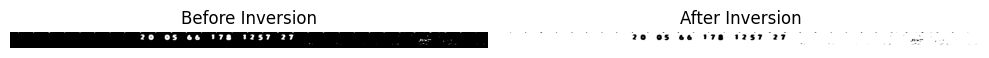


Results
Otsu threshold: 119.2
Inverted before processing: False
Detected horizontal edge rows: [79]
Number of edges detected: 1
Final float min: 0.000
Final float max: 1.000
Processing time: 1.278 seconds
Done


In [85]:
import time


test_paths = [
    Path(
        # r"L:\DATA\ISIS\2026-June-Model-Training\Cropped_Images\SSA-23\23-023\image005.png"
        # r"L:\DATA\ISIS\2026-June-Model-Training\Cropped_Images\SSA-23\23-001\image075.png"
        r"L:\DATA\ISIS\2026-June-Model-Training\Cropped_Images\SSA-23\23-001\image213.png"
    )
]


for test_path in test_paths:
    print("\n" + "=" * 80)
    print(f"Testing: {test_path}")
    print("=" * 80)

    start_time = time.perf_counter()

    if not test_path.exists():
        print(f"ERROR: File does not exist: {test_path}")
        continue

    # Read image
    gray = read_gray(test_path)

    if gray is None:
        print(f"ERROR: Could not read image: {test_path}")
        continue

    print("1. Contrast normalization")
    normalized = contrast_normalize(
        gray,
        show_transformation=True
    )

    print("2. Median denoising")
    denoised = denoise_image(
        normalized,
        method="median",
        show_transformation=True
    )

    print("3. Otsu binarization")
    binary_img, otsu_threshold = otsu_binarize(
        denoised,
        show_transformation=True
    )

    print("4. Background standardization")
    binary_img, was_inverted_before_processing = (
        ensure_black_background(
            binary_img,
            show_transformation=True
        )
    )

    print("5. Morphological closing")
    closed_img = morphologically_close(
        binary_img,
        iterations=1,
        show_transformation=True
    )

    print("6. Horizontal edge detection")
    edge_rows, horizontal_edges, row_strength = (
        detect_horizontal_edges(
            binary_img,
            min_line_length_fraction=0.03,
            max_line_gap=10,
            show_transformation=True,
            debug=True
        )
    )

    print("7. Strip removal")
    cleaned_img = remove_unwanted_strips(
        image=closed_img,
        detection_image=binary_img,
        min_line_length_fraction=0.03,
        max_line_gap=10,
        safety_padding=1,
        show_transformation=True,
        debug=True
    )

    print("8. Final inversion")
    inverted_img = invert_image(
        cleaned_img,
        show_transformation=True
    )

    final_float = normalize_to_float(inverted_img)

    elapsed_time = time.perf_counter() - start_time

    print("\nResults")
    print(f"Otsu threshold: {otsu_threshold:.1f}")
    print(
        "Inverted before processing: "
        f"{was_inverted_before_processing}"
    )
    print(f"Detected horizontal edge rows: {edge_rows}")
    print(f"Number of edges detected: {len(edge_rows)}")
    print(f"Final float min: {final_float.min():.3f}")
    print(f"Final float max: {final_float.max():.3f}")
    print(f"Processing time: {elapsed_time:.3f} seconds")
    print("Done")


# Main Helper Function

In [ ]:
def run_preprocessing_pipeline(
    image_paths,
    root_dir,
    output_dir,
    overwrite=False
):
    """
    Run the complete preprocessing pipeline on a collection of images.

    The input folder structure is reproduced inside output_dir.

    Processing flow:
        1. Read image as grayscale
        2. Apply contrast normalization
        3. Apply median denoising
        4. Apply Otsu binarization
        5. Temporarily standardize to a black background
        6. Preserve the pre-closing binary image for strip detection
        7. Apply morphological closing
        8. Detect horizontal edges from the pre-closing image
        9. Remove unwanted top and bottom strips from the closed image
        10. Invert to the final white-background format
        11. Save as uint8 PNG

    Parameters
    ----------
    image_paths:
        Iterable containing the input image paths.

    root_dir:
        Common input root directory. The relative folder structure below
        this directory is reproduced inside output_dir.

    output_dir:
        Root directory where processed images will be saved.

    overwrite:
        If False, output images that already exist are skipped.
        If True, existing output images are replaced.

    Returns
    -------
    summary:
        Dictionary containing processing counts.
    """
    root_dir = Path(root_dir)
    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    image_paths = [
        Path(image_path)
        for image_path in image_paths
    ]

    total_images = len(image_paths)

    processed_count = 0
    skipped_count = 0
    failed_count = 0
    temporary_inversion_count = 0

    failed_records = []

    for index, image_path in enumerate(
        image_paths,
        start=1
    ):
        try:
            # Reproduce the source folder structure in the output
            try:
                relative_path = image_path.relative_to(root_dir)
                relative_parent = relative_path.parent

            except ValueError:
                # Fallback if image_path is not located under root_dir
                relative_parent = Path()

            image_output_dir = (
                output_dir
                / relative_parent
            )

            image_output_dir.mkdir(
                parents=True,
                exist_ok=True
            )

            output_name = image_path.name
            output_path = (
                image_output_dir
                / output_name
            )

            if output_path.exists() and not overwrite:
                skipped_count += 1

                print(
                    f"[{index}/{total_images}] "
                    f"[SKIPPED - EXISTS] "
                    f"{output_path}"
                )

                continue

            # ---------------------------------------------------------
            # 1. LOAD IMAGE
            # ---------------------------------------------------------
            image = read_gray(
                image_path=image_path
            )

            if image is None:
                raise ValueError(
                    "Image could not be read."
                )

            # ---------------------------------------------------------
            # 2. CONTRAST NORMALIZATION
            # ---------------------------------------------------------
            image = contrast_normalize(
                image=image,
                show_transformation=False
            )

            # ---------------------------------------------------------
            # 3. DENOISING
            # ---------------------------------------------------------
            image = denoise_image(
                image=image,
                method="median",
                show_transformation=False
            )

            # ---------------------------------------------------------
            # 4. OTSU BINARIZATION
            # ---------------------------------------------------------
            image, otsu_threshold = otsu_binarize(
                image=image,
                show_transformation=False
            )

            # ---------------------------------------------------------
            # 5. STANDARDIZE PROCESSING BACKGROUND
            # ---------------------------------------------------------
            image, was_inverted_before_processing = (
                ensure_black_background(
                    image=image,
                    show_transformation=False
                )
            )

            if was_inverted_before_processing:
                temporary_inversion_count += 1

            # Preserve the binary image before closing.
            # This version is used only for horizontal-line detection,
            # as closing can join unrelated character strokes.
            binary_before_closing = image.copy()

            # ---------------------------------------------------------
            # 6. MORPHOLOGICAL CLOSING
            # ---------------------------------------------------------
            image = morphologically_close(
                image=image,
                iterations=1,
                erosion_kernel_size=(1, 2),
                dilation_kernel_size=(1, 2),
                show_transformation=False
            )

            # ---------------------------------------------------------
            # 7. STRIP REMOVAL
            # ---------------------------------------------------------
            image = remove_unwanted_strips(
                image=image,
                detection_image=binary_before_closing,
                min_line_length_fraction=0.03,
                max_line_gap=10,
                safety_padding=1,
                show_transformation=False,
                debug=False
            )

            # ---------------------------------------------------------
            # 8. FINAL OUTPUT POLARITY
            # ---------------------------------------------------------
            # Processing uses a black background. Final output should have black text on a white background
            final_image = invert_image(
                image=image,
                show_transformation=False
            )

            # Keep PNG output in uint8 format from 0 to 255.
            final_image = correct_image_type(
                final_image
            )

            # ---------------------------------------------------------
            # 9. SAVE IMAGE
            # ---------------------------------------------------------
            save_image(
                image=final_image,
                image_name=output_name,
                dir=image_output_dir
            )

            processed_count += 1

            print(
                f"[{index}/{total_images}] "
                f"[SAVED] {output_path} | "
                f"Otsu={otsu_threshold:.1f} | "
                f"Temporary inversion="
                f"{was_inverted_before_processing}"
            )

        except Exception as error:
            failed_count += 1

            failed_records.append({
                "image_path": str(image_path),
                "error": str(error)
            })

            print(
                f"[{index}/{total_images}] "
                f"[FAILED] {image_path}\n"
                f"Reason: {error}"
            )

    # Save a failure report when at least one image failed
    if failed_records:
        failed_df = pd.DataFrame(
            failed_records
        )

        save_df_to_csv(
            df=failed_df,
            csv_name="preprocessing_failures.csv",
            output_dir=output_dir
        )

    summary = {
        "total_selected": total_images,
        "processed": processed_count,
        "skipped_existing": skipped_count,
        "failed": failed_count,
        "white_background_inputs": temporary_inversion_count
    }

    print("\nPreprocessing complete.")
    print(
        f"Selected images: "
        f"{summary['total_selected']}"
    )
    print(
        f"Successfully processed: "
        f"{summary['processed']}"
    )
    print(
        f"Skipped existing: "
        f"{summary['skipped_existing']}"
    )
    print(
        f"Failed: "
        f"{summary['failed']}"
    )
    print(
        "White-background inputs temporarily inverted: "
        f"{summary['white_background_inputs']}"
    )

    return summary


def run_preprocessing(
    root_dir,
    excluded_subfolders,
    output_dir,
    max_images=None,
    overwrite=False,
    random_seed=None
):
    """
    Collect PNG images recursively and run the preprocessing pipeline.

    Parameters
    ----------
    root_dir:
        Root directory containing the cropped input images.

    excluded_subfolders:
        Iterable containing folder names that should not be processed.

    output_dir:
        Root output directory for processed images.

    max_images:
        Optional maximum number of images to process.
        Use None to process every collected image.

    overwrite:
        If False, existing output images are skipped.
        If True, existing output images are replaced.

    random_seed:
        Optional seed used when randomly selecting max_images.

    Returns
    -------
    summary:
        Dictionary returned by run_preprocessing_pipeline().
    """
    root_dir = Path(root_dir)
    output_dir = Path(output_dir)

    if not root_dir.exists():
        raise FileNotFoundError(
            f"Input directory does not exist: "
            f"{root_dir}"
        )

    if not root_dir.is_dir():
        raise NotADirectoryError(
            f"Input path is not a directory: "
            f"{root_dir}"
        )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    if excluded_subfolders is None:
        excluded_subfolders = set()
    else:
        excluded_subfolders = set(
            excluded_subfolders
        )

    # Collect images recursively while ignoring excluded folders
    image_paths, skipped_dirs = collect_png_images(
        root_dir=root_dir,
        excluded_subfolders=excluded_subfolders
    )

    # Convert to Path objects and sort for a predictable full run
    image_paths = sorted(
        Path(path)
        for path in image_paths
    )

    total_found = len(image_paths)

    # Optionally select a random subset.
    if max_images is not None:
        if not isinstance(max_images, int):
            raise TypeError(
                "max_images must be an integer or None."
            )

        if max_images <= 0:
            raise ValueError(
                "max_images must be greater than zero "
                "or None."
            )

        number_to_select = min(
            max_images,
            total_found
        )

        random_generator = random.Random(
            random_seed
        )

        image_paths = random_generator.sample(
            image_paths,
            number_to_select
        )

        # Sort the sampled paths so the processing order and logs remain easy to inspect
        image_paths = sorted(
            image_paths
        )

    print(
        f"{total_found} PNG images were found."
    )

    print(
        f"{len(image_paths)} PNG images were selected "
        "for processing."
    )

    print(
        f"{len(skipped_dirs)} subfolders were excluded "
        "during image retrieval."
    )

    if not image_paths:
        print(
            "No PNG images were found. "
            "Nothing to process."
        )

        return {
            "total_selected": 0,
            "processed": 0,
            "skipped_existing": 0,
            "failed": 0,
            "white_background_inputs": 0
        }

    # Save the inventory of images selected for this run
    save_image_inventory(
        image_paths=image_paths,
        output_dir=output_dir
    )

    # Save excluded/skipped folder information
    skipped_df = pd.DataFrame({
        "skipped_dir": [
            str(path)
            for path in skipped_dirs
        ]
    })

    save_df_to_csv(
        df=skipped_df,
        csv_name="skipped_folders.csv",
        output_dir=output_dir
    )

    return run_preprocessing_pipeline(
        image_paths=image_paths,
        root_dir=root_dir,
        output_dir=output_dir,
        overwrite=overwrite
    )

# Main Preprocessing

In [88]:
def main():
    # Root folder containing the cropped metadata images
    root_dir = Path(
        r"L:\DATA\ISIS\2026-June-Model-Training\Cropped_Images\SSA-23"
    )

    # Processed images will be saved here
    # The original subfolder structure will be preserved
    output_dir = Path(
        r"L:\DATA\ISIS\2026-June-Model-Training\Preprocessed_Images\SSA-23"
    )

    excluded_subfolders = {
        "23-004",
        "23-016",
        "23-019",
        "23-022",
        "23-025",
        "23-044",
        "23-051",
        "23-057",
        "23-062",
        "23-069",
        "23-072"
    }

    summary = run_preprocessing(
        root_dir=root_dir,
        excluded_subfolders=excluded_subfolders,
        output_dir=output_dir,

        # None processes every image
        # Set this to 1, 10, etc. for a smaller test
        max_images=None,

        # False skips output images that already exist
        overwrite=False,

        # Makes random sampling reproducible when max_images is used
        random_seed=42
    )

    print("\nRun summary:")
    print(summary)


if __name__ == "__main__":
   main()

18436 PNG images were found.
18436 PNG images were selected for processing.
11 subfolders were excluded during image retrieval.
Otsu=144.0, Adjusted=108.0
[1/18436] [SAVED] L:\DATA\ISIS\2026-June-Model-Training\Preprocessed_Images\SSA-23\23-001\image001.png | Otsu=108.0 | Temporary inversion=False
Otsu=85.0, Adjusted=63.8
[2/18436] [SAVED] L:\DATA\ISIS\2026-June-Model-Training\Preprocessed_Images\SSA-23\23-001\image002.png | Otsu=63.8 | Temporary inversion=True
Otsu=143.0, Adjusted=107.2
[3/18436] [SAVED] L:\DATA\ISIS\2026-June-Model-Training\Preprocessed_Images\SSA-23\23-001\image003.png | Otsu=107.2 | Temporary inversion=False
Otsu=140.0, Adjusted=105.0
[4/18436] [SAVED] L:\DATA\ISIS\2026-June-Model-Training\Preprocessed_Images\SSA-23\23-001\image004.png | Otsu=105.0 | Temporary inversion=False
Otsu=138.0, Adjusted=103.5
[5/18436] [SAVED] L:\DATA\ISIS\2026-June-Model-Training\Preprocessed_Images\SSA-23\23-001\image005.png | Otsu=103.5 | Temporary inversion=False
Otsu=144.0, Adjusted=